In [910]:
import sys
sys.path.append("..")
import os
print(os.listdir(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
from src.utils import plot_real_vs_pred, learning_curve, build_features
from src.metrics import print_metrics
from src.data_splitting import split_data, cross_val
from src.preprocessing import read_data, plot_city, first_changes, change_units, adjust_low_prices, choose_thresholds, normalize_test, normalize_train, one_hot_encoder_tipo, eliminate_low_prices
from src.models import LinearRegression, denormalize_dataset, denormalize_prediction

['.claude', '.git', 'data', 'notebooks', 'README.md', 'requirements.txt', 'src']


In [911]:
# Load raw datasets and inspect a random sample for missing values and basic statistics
data_train, data_test = read_data("../data/raw/casas_dev.csv", "../data/raw/casas_test.csv")
partition = data_train.sample(100)

print(partition)
print(partition.describe())
print(data_train.info())
print(partition.isna().sum())

             precio   tipo        Área  metros_cubiertos unidades  ambientes  \
82     36321.412866   casa  239.183230        122.970735       m2          7   
305    25732.567909   casa  251.360488        183.046624       m2         10   
621   176405.500071  depto  890.794420        876.972596     sqft          8   
1074    9125.800587  depto   79.782869         78.446653       m2          6   
299    30330.392735   casa  246.583108        110.101693       m2         10   
...             ...    ...         ...               ...      ...        ...   
455    87903.055361   casa  241.225868        133.032005       m2         10   
452    41765.035190   casa  251.354695        101.875562       m2          5   
947   191807.331590  depto  690.186759        668.257418     sqft          5   
406    63724.951440   casa  242.667747        193.668745       m2         10   
1118  105847.605464  depto  653.244541        635.694466     sqft          6   

      pisos  pileta        lat        l

From an initial sample of 100 observations, cases of properties with zero price values and missing data in the floors and age columns were identified. Regarding price, values equal to zero would directly mislead the model, and there is no clear way to estimate them, so these observations will be removed from the dataset. For the number of floors, it will be evaluated based on two factors: the type of property and its price. Finally, for the age variable, the mean value of the column will be calculated and used to replace missing data.

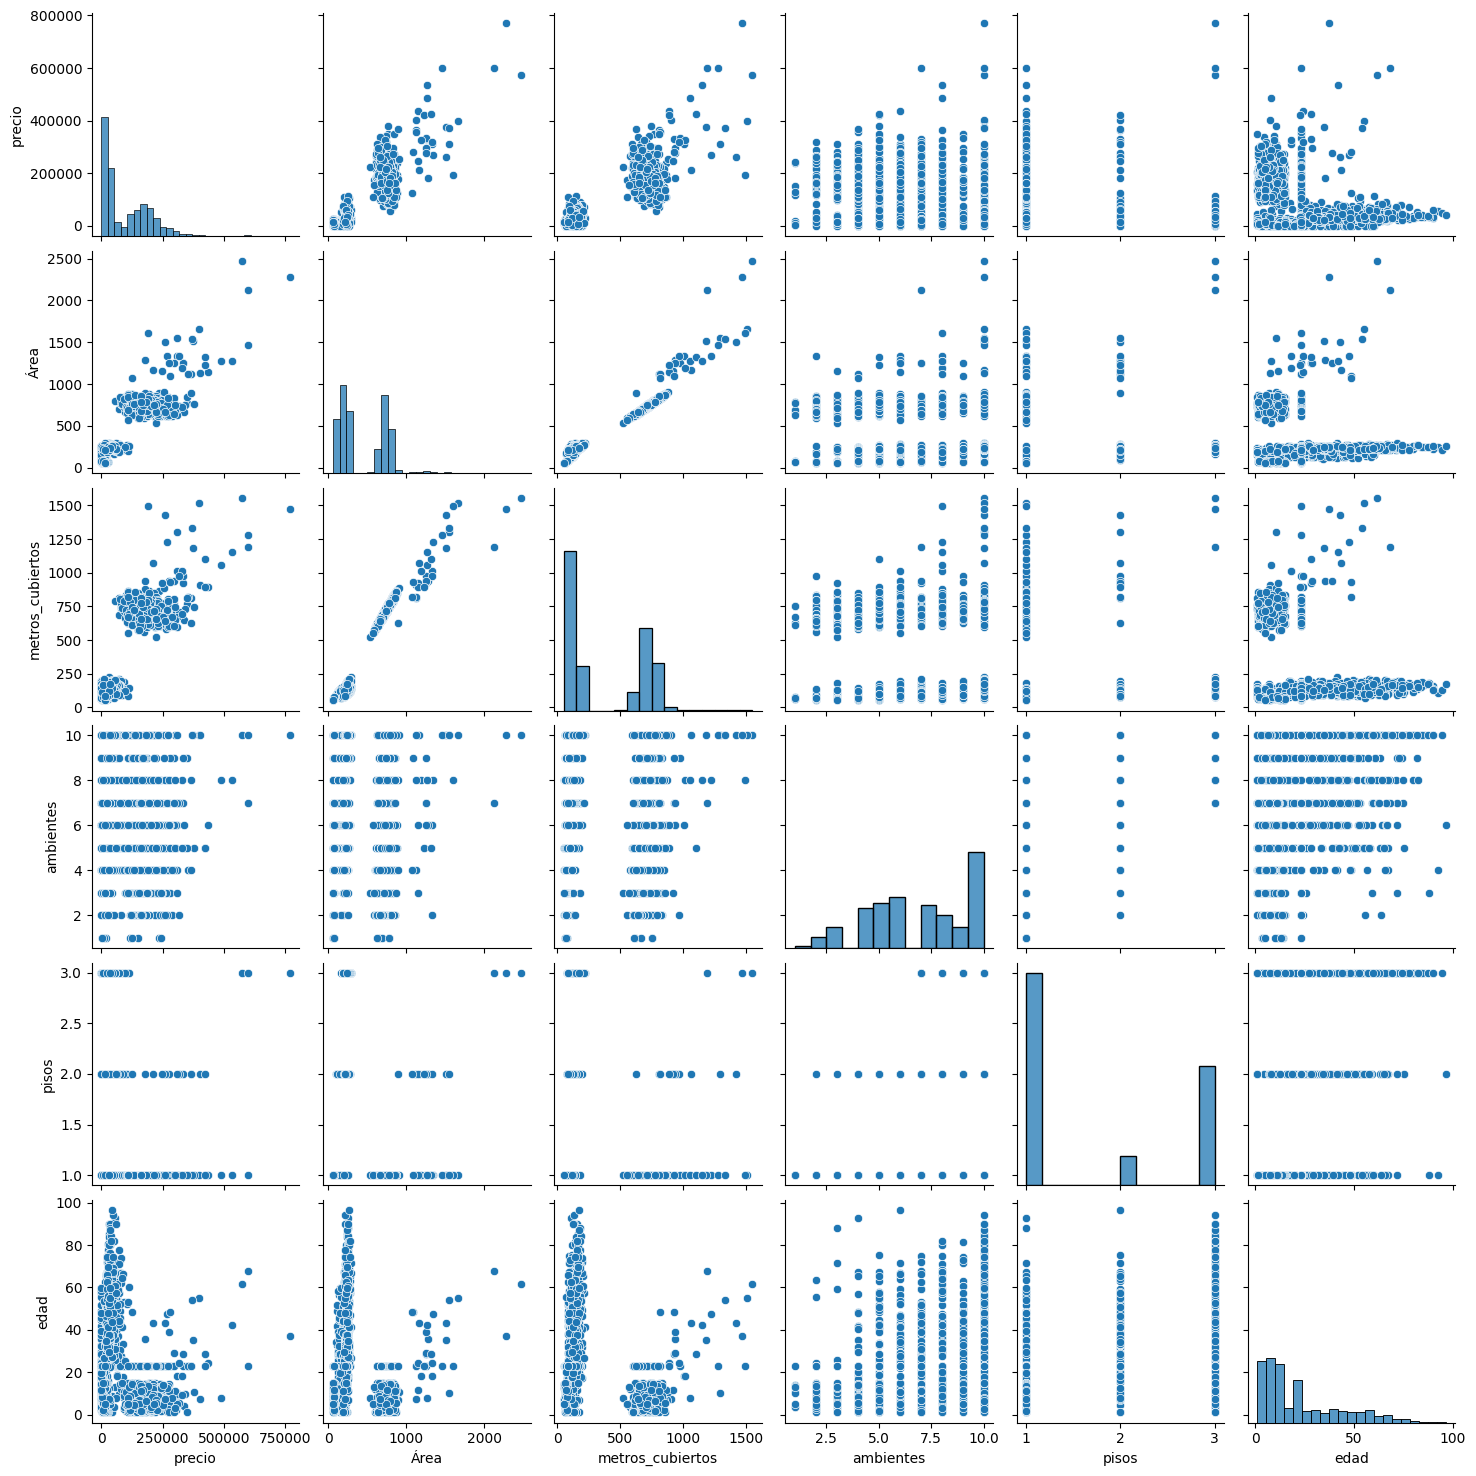

In [912]:
# Initial cleaning: remove zero-price rows, impute missing floors and age; pairplot for correlation overview
data_train = first_changes(data_train)
data_test = first_changes(data_test)

features_analysis = ["precio", "Área", "metros_cubiertos", "ambientes", "pisos", "edad"]
sns.pairplot(data_train[features_analysis])
plt.show()

From the analysis of the histograms and scatter plots, no strong conclusions can be drawn regarding the distributions or correlations of the variables. Therefore, it will be necessary to apply transformations to better understand the behavior of the features and to facilitate the identification of potential outliers.
A positive trend can be observed in the scatter plot of price versus covered area, suggesting a linear relationship between these variables. In contrast, the relationship between price and total area appears more dispersed, indicating that covered area may be a more consistent predictor of price. Other variables, such as number of rooms and floors, display discrete patterns in the scatter plots, forming vertical groupings rather than continuous relationships. This suggests that their impact on price may not be strictly linear. Additionally, the age variable shows a high concentration of lower values with a long tail, indicating a skewed distribution that may not contribute strongly to linear patterns without transformation.
Overall, several features exhibit skewed or irregular distributions, as observed in the histograms, supporting the use of logarithmic transformations to stabilize variance and improve interpretability.

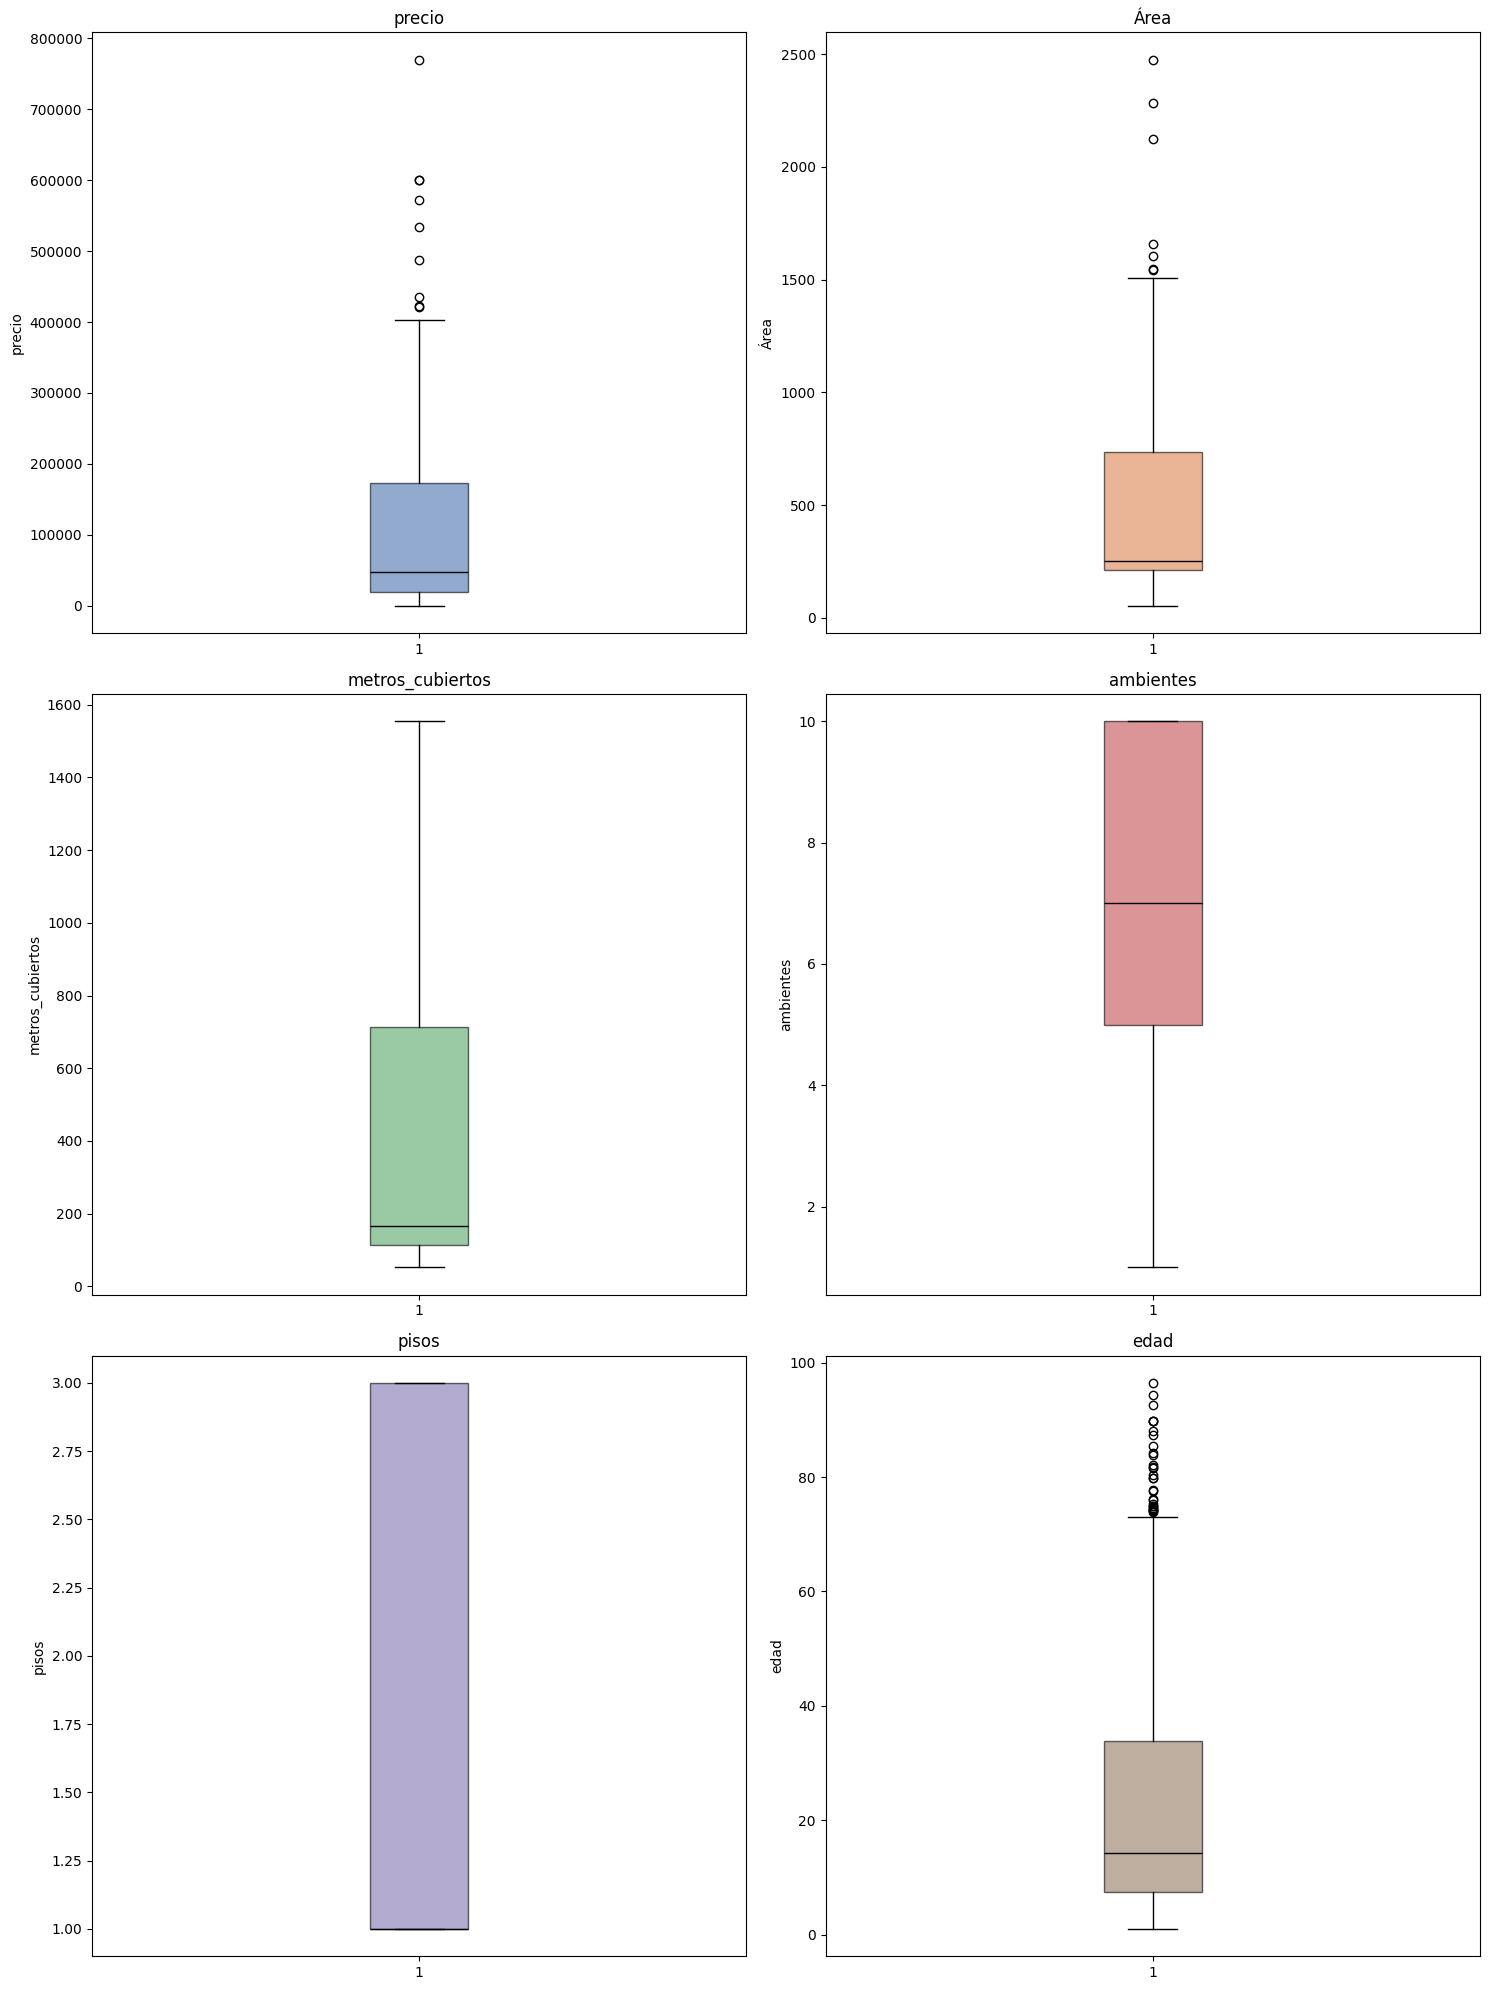

In [913]:
# Colored boxplots to inspect the distribution and outliers for each feature
n_features = len(features_analysis)
n_cols = 2
n_rows = 3

colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 20))
axes = axes.ravel()

for i, feature in enumerate(features_analysis):
    bp = axes[i].boxplot(data_train[feature].dropna(), patch_artist=True)
    bp["boxes"][0].set_facecolor(colors[i % len(colors)])
    bp["boxes"][0].set_alpha(0.6)
    bp["medians"][0].set_color("black")
    axes[i].set_title(feature)
    axes[i].set_ylabel(feature)


plt.tight_layout()

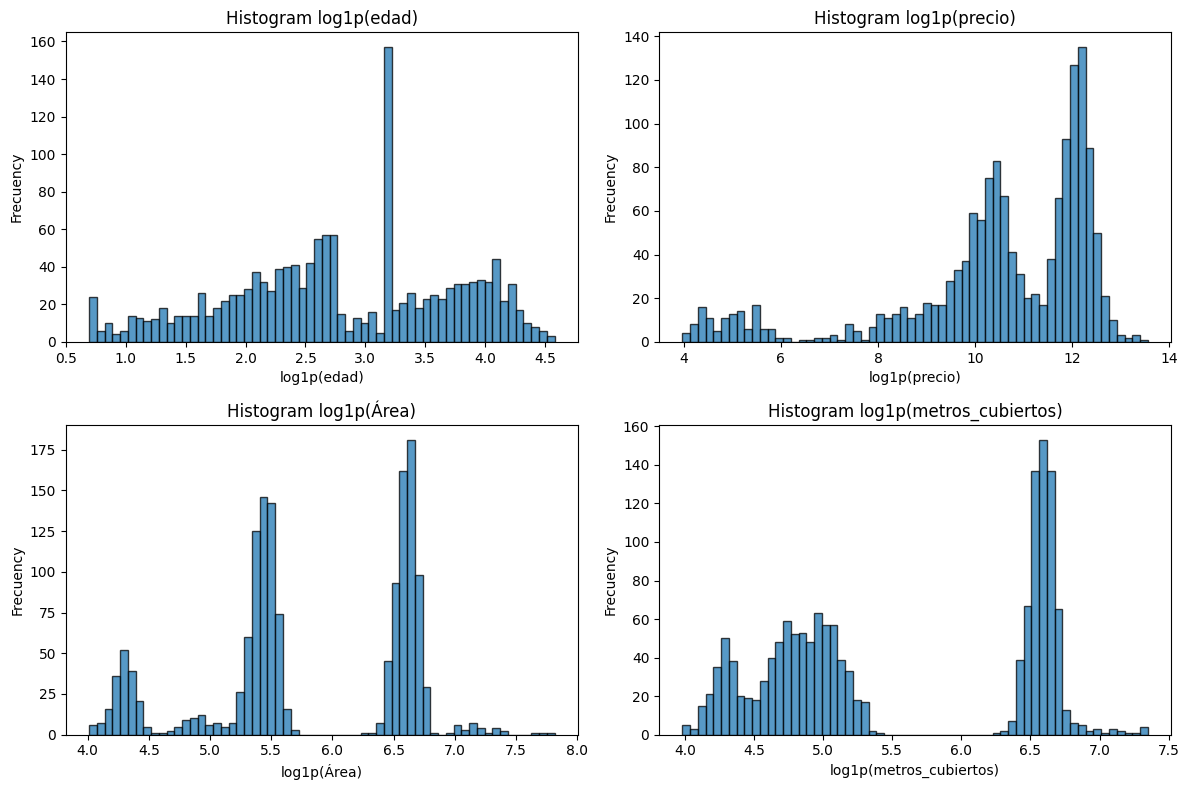

In [914]:
# Log-transformed histograms to assess skewness in continuous features
hist_features = ["edad", "precio", "Área", "metros_cubiertos"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, feature in enumerate(hist_features):
    values = data_train[feature].dropna()
    log_values = np.log1p(values)
    axes[i].hist(log_values, bins=60, edgecolor="black", alpha=0.75)
    axes[i].set_title(f"Histogram log1p({feature})")
    axes[i].set_xlabel(f"log1p({feature})")
    axes[i].set_ylabel("Frecuency")

plt.tight_layout()
plt.show()

A logarithmic transformation was applied to continuous variables with the aim of reducing skewness and stabilizing variance. However, the histograms do not show a significant improvement after the transformation, as they still present irregular distributions.
It can also be observed that in variables such as Area and covered surface, multiple peaks persist in the distribution, suggesting the presence of subgroups within the dataset. Price also shows several peaks, indicating that, similar to area, it may follow multiple underlying distributions. In the case of age, the transformation does not lead to a clear improvement either, as the distribution remains uneven and exhibits concentrated regions, suggesting that this variable may not follow a well-behaved continuous pattern.
As no clear patterns are observed, there is limited evidence to draw strong conclusions regarding the presence of outliers. While the boxplots indicate values lying beyond 1.5 times the interquartile range, it cannot be conclusively determined that these values are true outliers, given the lack of clear understanding of the underlying feature distributions.

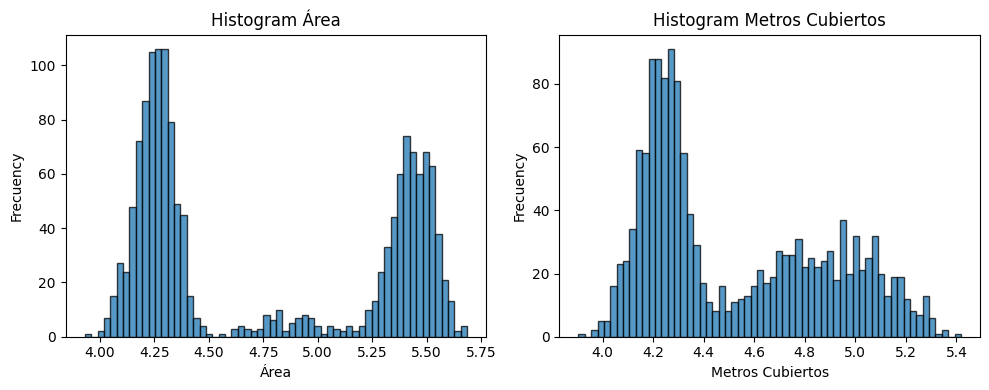

In [915]:
# Convert all area columns from sqft to m², then check distributions after unit unification
data_train = change_units(data_train)
data_test = change_units(data_test)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
valueA = np.log1p(data_train["Área"].dropna())
valueM = np.log1p(data_train["metros_cubiertos"].dropna())

axes[0].hist(valueA, bins=60, edgecolor="black", alpha=0.75)
axes[0].set_title("Histogram Área")
axes[0].set_xlabel("Área")
axes[0].set_ylabel("Frecuency")

axes[1].hist(valueM, bins=60, edgecolor="black", alpha=0.75)
axes[1].set_title("Histogram Metros Cubiertos")
axes[1].set_xlabel("Metros Cubiertos")
axes[1].set_ylabel("Frecuency")

plt.tight_layout()
plt.show()

After converting all values to square meters, the distributions of area and covered area remain irregular and exhibit multiple peaks. This indicates that the issue is not related to inconsistent units, but rather to the presence of different subgroups within the dataset.

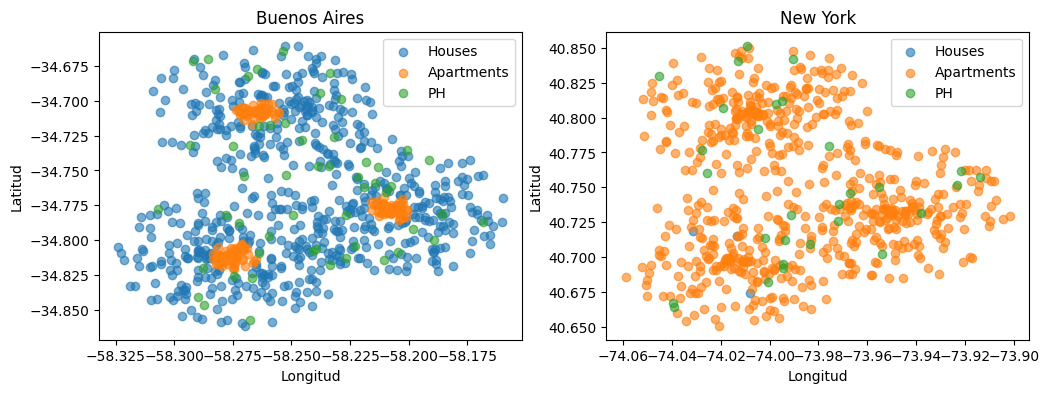

In [916]:
# Split properties by type (house/apt/ph) and city, then plot geographic scatter
houses = data_train[data_train['tipo'] == 'casa']
apts = data_train[data_train['tipo'] == 'depto']
ph = data_train[data_train['tipo'] == 'ph']

housesBA = houses[houses["lat"] < 0]
aptsBA = apts[apts["lat"] < 0]
phBA = ph[ph["lat"] < 0]

housesNY = houses[houses["lat"] > 0]
aptsNY = apts[apts["lat"] > 0]
phNY = ph[ph["lat"] > 0]

plot_city(housesBA, aptsBA, phBA, housesNY, aptsNY, phNY, "Buenos Aires", "New York")

After segmenting the dataset by location, it becomes evident that New York is predominantly composed of apartments, while Buenos Aires contains a higher proportion of houses. This structural difference helps explain the multiple peaks observed in the distributions of both area and covered surface.
In particular, houses tend to have larger areas compared to apartments, which contributes to the separation of the data into distinct clusters. As a result, when both cities are analyzed together, the combined distribution appears irregular and multimodal rather than following a single pattern. The same seems to happen to the price variable, where the presence of different markets leads to a mixed distribution. Therefore, location and property type play a key role in shaping the behavior of the dataset and should be explicitly considered in the modeling process.

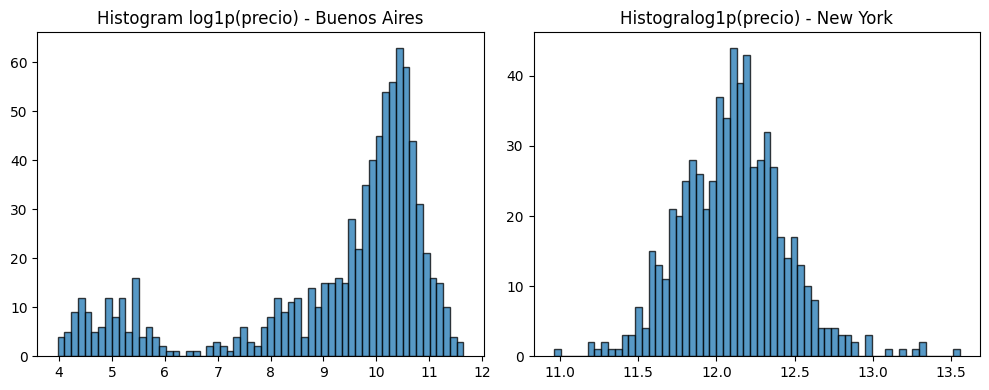

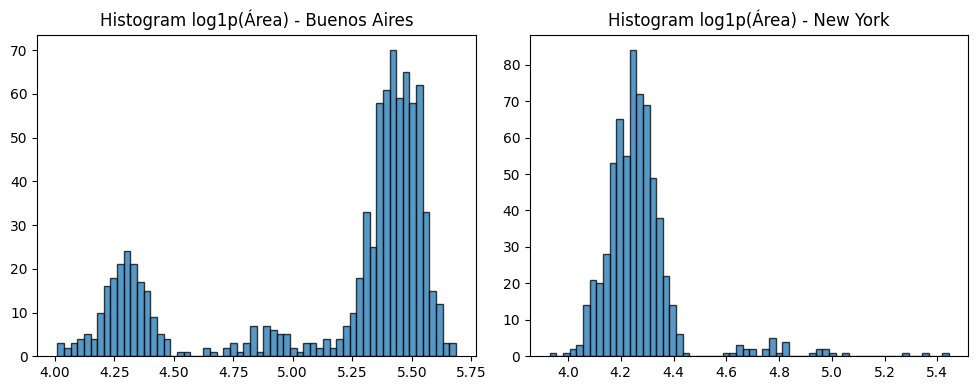

In [917]:
# Compare log-price and log-area distributions between Buenos Aires and New York
pricesBA = data_train[data_train["lat"] < 0]["precio"]
pricesNY = data_train[data_train["lat"] > 0]["precio"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(np.log1p(pricesBA), bins=60, edgecolor="black", alpha=0.75)
axes[0].set_title("Histogram log1p(precio) - Buenos Aires")
axes[1].hist(np.log1p(pricesNY), bins=60, edgecolor="black", alpha=0.75)
axes[1].set_title("Histogralog1p(precio) - New York")
plt.tight_layout()
plt.show()

areasBA = data_train[data_train["lat"] < 0]["Área"]
areasNY = data_train[data_train["lat"] > 0]["Área"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(np.log1p(areasBA), bins=60, edgecolor="black", alpha=0.75)
axes[0].set_title("Histogram log1p(Área) - Buenos Aires") 
axes[1].hist(np.log1p(areasNY), bins=60, edgecolor="black", alpha=0.75)
axes[1].set_title("Histogram log1p(Área) - New York")
plt.tight_layout()
plt.show()

The distribution of prices in New York appears clearly concentrated and approximately symmetric, indicating that it follows a normal distribution. The data follows a well-defined shape, with most observations clustered around a central range and no evident irregularities, probably due to the vast quantity of apartments. A similar behavior can be observed in the distribution of area in New York, which is mostly unimodal and concentrated, implying a more homogeneous structure in property sizes.
On the other hand, Buenos Aires presents a noticeably different behavior, with a distribution characterized by multiple peaks, suggesting the presence of two normals. This shows that there are distinct subgroups within the dataset, most likely driven by differences between houses and apartments. Similarly, the area distribution in Buenos Aires is clearly multimodal, reinforcing the argument previously mentioned.

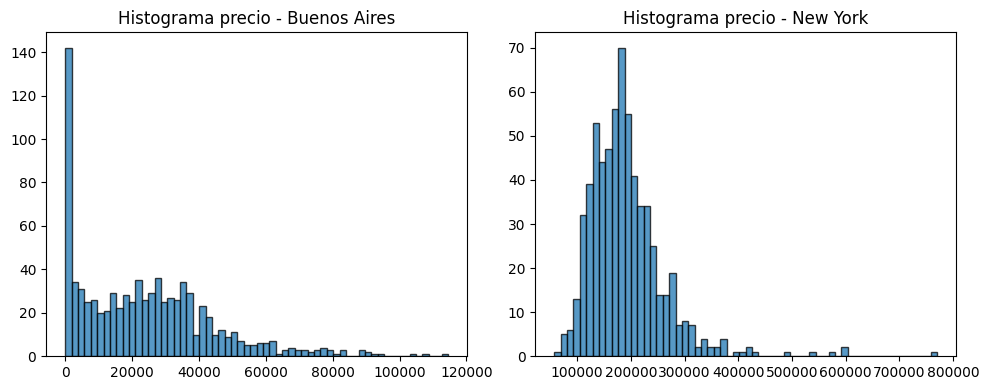

In [918]:
# Raw (non-log) price histograms to visualize the scale differences between cities
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(pricesBA, bins=60, edgecolor="black", alpha=0.75)
axes[0].set_title("Histograma precio - Buenos Aires")
axes[1].hist(pricesNY, bins=60, edgecolor="black", alpha=0.75)
axes[1].set_title("Histograma precio - New York")

plt.tight_layout()
plt.show()


Buenos Aires' histogram exhibits a concentration of low values that deviate from the main distribution, it makes no sense that the price of some houses are near 0. As a result, it will be necessary to apply transformations or adjustments to ensure that the model can more accurately learn the underlying relationships.

Threshold Buenos Aires: 3469.419593678956


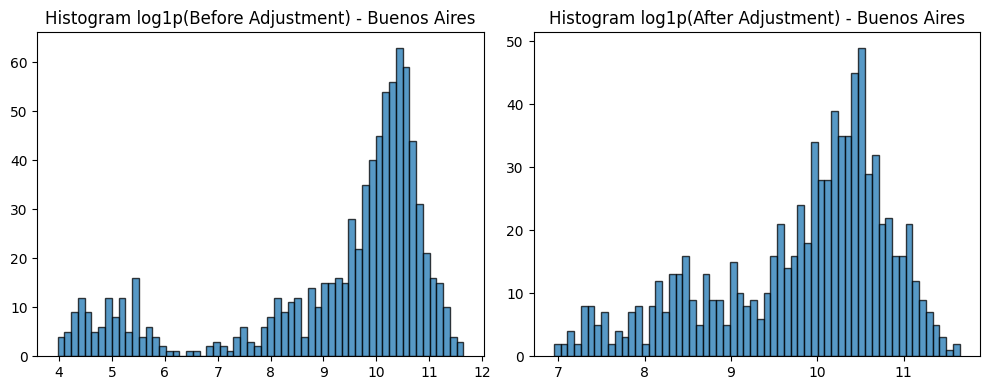

In [919]:
# Detect suspiciously low BA prices, scale them up, and compare distributions before/after
old_data = data_train.copy()
new_data = data_train.copy()

thresholdBA = choose_thresholds(new_data, 0.2)
print(f"Threshold Buenos Aires: {thresholdBA}")

new_data = adjust_low_prices(new_data, thresholdBA, factorBA=20)

pricesBA = new_data[new_data["lat"] < 0]["precio"]
old_pricesBA = old_data[old_data["lat"] < 0]["precio"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(np.log1p(old_pricesBA), bins=60, edgecolor="black", alpha=0.75)
axes[0].set_title("Histogram log1p(Before Adjustment) - Buenos Aires")
axes[1].hist(np.log1p(pricesBA), bins=60, edgecolor="black", alpha=0.75)
axes[1].set_title("Histogram log1p(After Adjustment) - Buenos Aires")
plt.tight_layout()
plt.show()

After adjusting the near-zero price values in the Buenos Aires dataset, the log-transformed histogram exhibits a much smoother and more regular shape, closer to a normal distribution. This improvement reduces distortion in the data and allows the model to better capture underlying patterns, ultimately leading to more reliable price predictions. 
Nevertheless, after testing several models, the results showed that leaving the prices unadjusted led to better predictions.

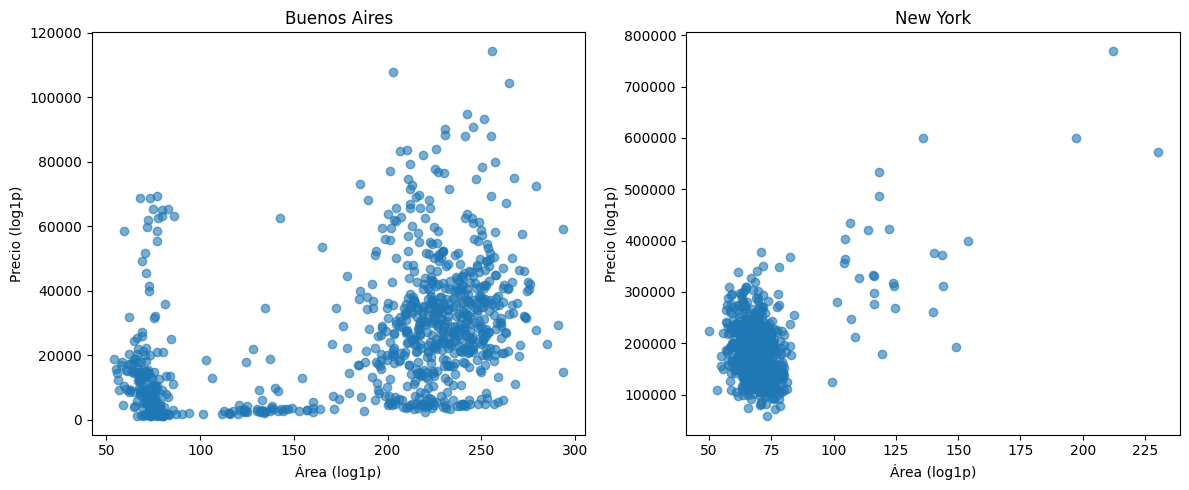

In [920]:
# Scatter of area vs price per city to visually assess linearity of the relationship
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(areasBA, pricesBA, alpha=0.6)
axes[0].set_title("Buenos Aires")
axes[0].set_xlabel("Área (log1p)")
axes[0].set_ylabel("Precio (log1p)")
axes[1].scatter(areasNY, pricesNY, alpha=0.6)
axes[1].set_title("New York")
axes[1].set_xlabel("Área (log1p)")
axes[1].set_ylabel("Precio (log1p)")

plt.tight_layout()
plt.show()

The relationship between area and price differs between Buenos Aires and New York. In Buenos Aires, the data is highly dispersed, showing no clear linear pattern. This suggests that area alone is not a strong predictor of price, likely due to the presence of different property types. In contrast, New York shows a more concentrated distribution with a clearer positive relationship between area and price. Overall, this highlights the importance of including location as a key variable in the model.

In [921]:
# One-hot encode property type, perform train/val split per city, and z-score normalize features
features = ["precio", "Área", "metros_cubiertos", "ambientes", "pisos", "lat", "lon", "edad"]
data_train = one_hot_encoder_tipo(data_train)
data_test = one_hot_encoder_tipo(data_test)

train_set, val_set = split_data(data_train.copy())

data_train.to_csv("../data/processed/casas_dev_processed.csv", index=False)
data_test.to_csv("../data/processed/casas_test_processed.csv", index=False)

train_ba = train_set[train_set["lat"] < 0]
train_ny = train_set[train_set["lat"] > 0]
val_ba = val_set[val_set["lat"] < 0]
val_ny = val_set[val_set["lat"] > 0]
test_ba = data_test[data_test["lat"] < 0]
test_ny = data_test[data_test["lat"] > 0]

train_ba_norm, statistics_ba = normalize_train(train_ba.copy(), features)
train_ny_norm, statistics_ny = normalize_train(train_ny.copy(), features)

val_ba_norm = normalize_test(val_ba.copy(), features, statistics_ba)
val_ny_norm = normalize_test(val_ny.copy(), features, statistics_ny)

test_ba_norm = normalize_test(test_ba.copy(), features, statistics_ba)
test_ny_norm = normalize_test(test_ny.copy(), features, statistics_ny)

data_train_ba = pd.concat([train_ba, val_ba])
data_train_ny = pd.concat([train_ny, val_ny])

data_train_ba_norm = pd.concat([train_ba_norm, val_ba_norm])
data_train_ny_norm = pd.concat([train_ny_norm, val_ny_norm])

In [922]:
# Verify that pseudo-inverse and gradient descent converge to the same weights
city_datas = [("Buenos Aires", data_train_ba_norm), ("Nueva York", data_train_ny_norm)]

for ciudad, data in city_datas:
    print(f"\n{'='*40}\n{ciudad}\n{'='*40}")
    
    # One feature
    X = data[["Área"]]
    y = data["precio"]

    model = LinearRegression(X, y)
    weights1 = model.pseudo_inverse()
    weights2 = model.gradient_descent()

    print("-- One feature --")
    print("Weights from Pseudo-inverse:\n", weights1)
    print("Weights from Gradient Descent:\n", weights2)
    model.print_coefficients()

    # Multiple features
    X = data[["Área", "ambientes", "metros_cubiertos", "edad"]]
    y = data["precio"]

    model = LinearRegression(X, y)
    weights1 = model.pseudo_inverse()
    weights2 = model.gradient_descent()

    print("-- Multiple features --")
    print("Weights from Pseudo-inverse:\n", weights1)
    print("Weights from Gradient Descent:\n", weights2)
    model.print_coefficients()


Buenos Aires
-- One feature --
Weights from Pseudo-inverse:
 [0.01101775 0.5174423 ]
Weights from Gradient Descent:
 [0.01101776 0.51744228]
bias: optimum weight = 0.011017757695498573
Área: optimum weight = 0.5174422834249885
-- Multiple features --
Weights from Pseudo-inverse:
 [ 0.00624319  0.38535884 -0.05049209 -0.04859996  0.32487693]
Weights from Gradient Descent:
 [ 0.00624316  0.38535548 -0.05049287 -0.04859731  0.32487727]
bias: optimum weight = 0.006243157346653392
Área: optimum weight = 0.3853554824852236
ambientes: optimum weight = -0.05049287486112782
metros_cubiertos: optimum weight = -0.04859731478153088
edad: optimum weight = 0.32487726627243796

Nueva York
-- One feature --
Weights from Pseudo-inverse:
 [-0.01171984  0.54000763]
Weights from Gradient Descent:
 [-0.01171985  0.54000727]
bias: optimum weight = -0.011719853171899235
Área: optimum weight = 0.5400072694071039
-- Multiple features --
Weights from Pseudo-inverse:
 [-0.00615029  1.33771761  0.04937207 -0.854

The weights obtained using both methods are nearly identical, indicating that the implementation is consistent and correctly converges to the optimal solution. This behavior is observed in both the single-feature and multi-feature cases, confirming that the model generalizes properly across different input dimensions. Additionally, the agreement between the pseudo-inverse solution and gradient descent demonstrates that the optimization procedure has been implemented correctly and is able to reach the global minimum of the cost function.

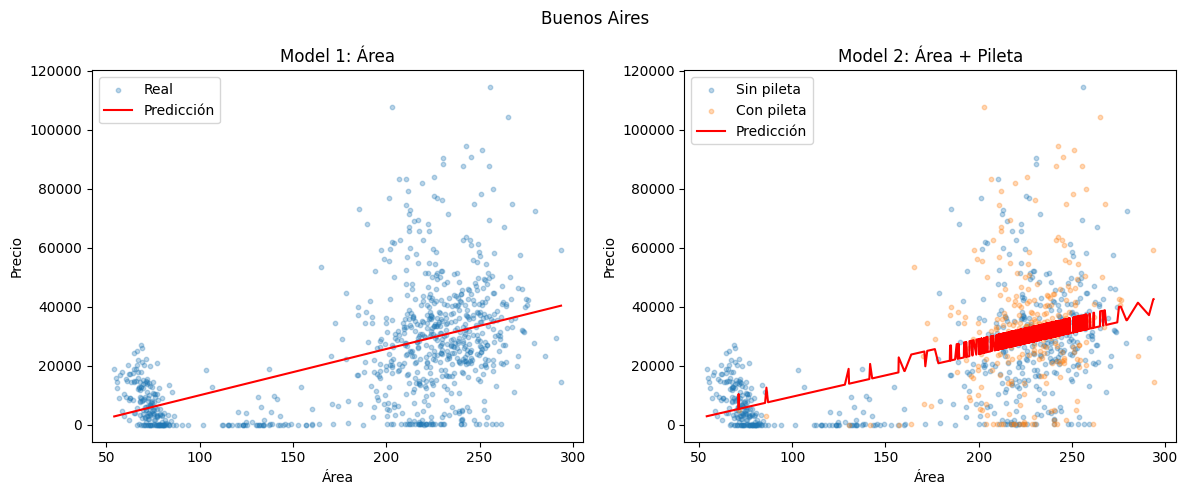

Nueva York: 'pileta' is always 0


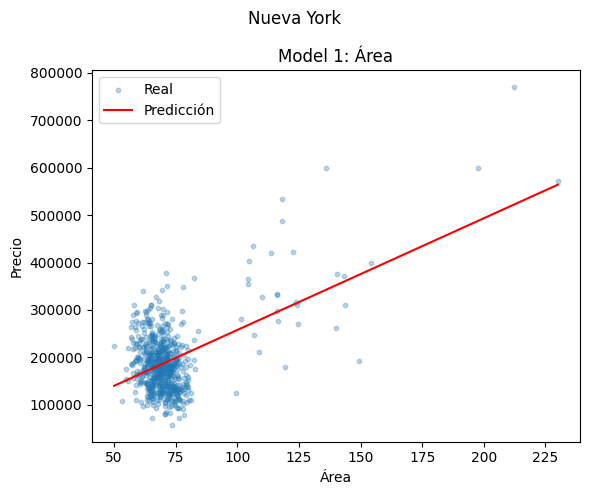

In [923]:
# M1 (area only) and M2 (area + pool indicator): fit and plot regression lines
city_datas_stats = [("Buenos Aires", data_train_ba_norm, statistics_ba), ("Nueva York", data_train_ny_norm, statistics_ny)]

for ciudad, data, stats in city_datas_stats:
    data["pileta"] = data["pileta"].astype(int)

    M1 = LinearRegression(data[["Área"]], data["precio"])
    M1.pseudo_inverse()

    use_M2 = data["pileta"].nunique() > 1

    if use_M2:
        M2 = LinearRegression(data[["Área", "pileta"]], data["precio"])
        M2.pseudo_inverse()
        X2_real, y_real2, y_pred2 = denormalize_dataset(M2, stats)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    else:
        print(f"{ciudad}: 'pileta' is always 0")
        fig, axes = plt.subplots(1, 1, figsize=(6, 5))
        axes = [axes]

    fig.suptitle(ciudad)

    # ---- MODEL 1 ----
    X1_real, y_real1, y_pred1 = denormalize_dataset(M1, stats)

    sort_idx1 = np.argsort(X1_real["Área"])
    axes[0].scatter(X1_real["Área"], y_real1, alpha=0.3, s=10, label="Real")
    axes[0].plot(X1_real["Área"][sort_idx1], y_pred1[sort_idx1], color="red", label="Predicción")
    axes[0].set_title("Model 1: Área")
    axes[0].set_xlabel("Área")
    axes[0].set_ylabel("Precio")
    axes[0].legend()

    # ---- MODEL 2  ----
    if use_M2:
        sort_idx2 = np.argsort(X2_real["Área"])
        sin_pileta = X2_real["pileta"] == 0
        con_pileta = X2_real["pileta"] == 1

        axes[1].scatter(X2_real["Área"][sin_pileta], y_real2[sin_pileta], alpha=0.3, s=10, label="Sin pileta")
        axes[1].scatter(X2_real["Área"][con_pileta], y_real2[con_pileta], alpha=0.3, s=10, label="Con pileta")
        axes[1].plot(X2_real["Área"][sort_idx2], y_pred2[sort_idx2], color="red", label="Predicción")

        axes[1].set_title("Model 2: Área + Pileta")
        axes[1].set_xlabel("Área")
        axes[1].set_ylabel("Precio")
        axes[1].legend()

    plt.tight_layout()
    plt.show()



As New York properties are primarily apartments and penthouses, which do not include pools, the analysis is conducted exclusively on housing data from Buenos Aires.

The model suggests that having a pool is associated with a slight increase in property prices. However, this effect appears to be relatively weak and not statistically dominant. The dispersion observed in the data indicates that the presence of a pool is not a key determinant of price. In fact, there are multiple cases where houses with a pool and similar area to those without one are priced equally or even lower. This overlap highlights that other variables play a much more significant role in explaining price variation. So, while a pool may add some marginal value, it does not appear to be a decisive factor in property valuation within this dataset.

Buenos Aires - Model 3 (Train) - Metrics:
  MSE: 208539604.56
  MAE: 10053.89
  RMSE: 14440.90
Buenos Aires - Model 3 (Validation) - Metrics:
  MSE: 182251681.78
  MAE: 9439.51
  RMSE: 13500.06


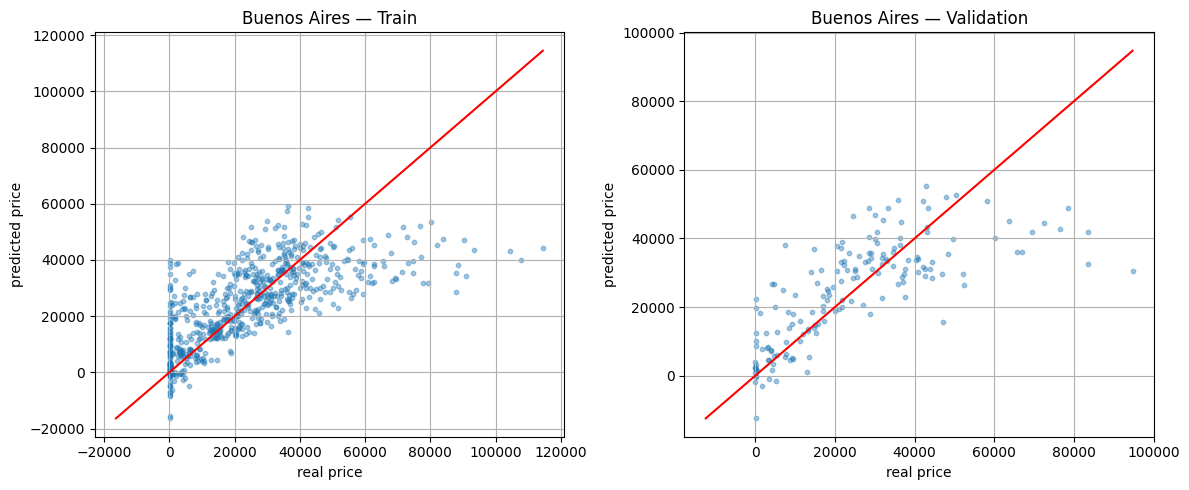

Nueva York - Model 3 (Train) - Metrics:
  MSE: 2302971763.69
  MAE: 38063.30
  RMSE: 47989.29
Nueva York - Model 3 (Validation) - Metrics:
  MSE: 2099187969.85
  MAE: 34851.79
  RMSE: 45816.90


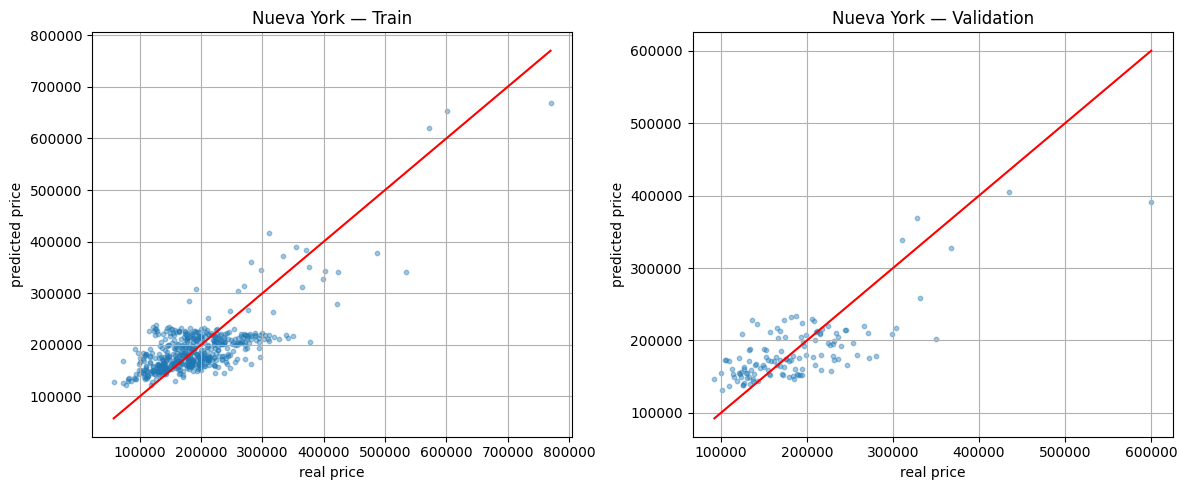

In [924]:
# M3: full set of base features — train and evaluate on train/validation per city
city_datas_stats = [("Buenos Aires", train_ba_norm, val_ba, val_ba_norm, statistics_ba), ("Nueva York", train_ny_norm, val_ny, val_ny_norm, statistics_ny)]
featuresM3 = ["Área", "ambientes", "metros_cubiertos", "edad", "pisos", "tipo_casa", "tipo_depto","lat", "lon"]

for ciudad, data, val_data, val_data_norm, stats in city_datas_stats:
    X3_train = data[featuresM3]
    y = data["precio"]
    X3_val = val_data_norm[featuresM3]
    y3_val = val_data["precio"]

    M3 = LinearRegression(X3_train, y)
    M3.pseudo_inverse()

    _, y3_real, y3_pred = denormalize_dataset(M3, stats)
    print_metrics(y3_real, y3_pred, title=f"{ciudad} - Model 3 (Train)")

    y3_pred_val = denormalize_prediction(M3, X3_val, stats)
    print_metrics(y3_val, y3_pred_val, title=f"{ciudad} - Model 3 (Validation)")

    plot_real_vs_pred(y3_real, y3_pred, y3_val, y3_pred_val, title=ciudad)

Buenos Aires - Model 4 (Train) - Metrics:
  MSE: 201858279.40
  MAE: 9981.19
  RMSE: 14207.68
Buenos Aires - Model 4 (Validation) - Metrics:
  MSE: 196489248.01
  MAE: 9967.83
  RMSE: 14017.46


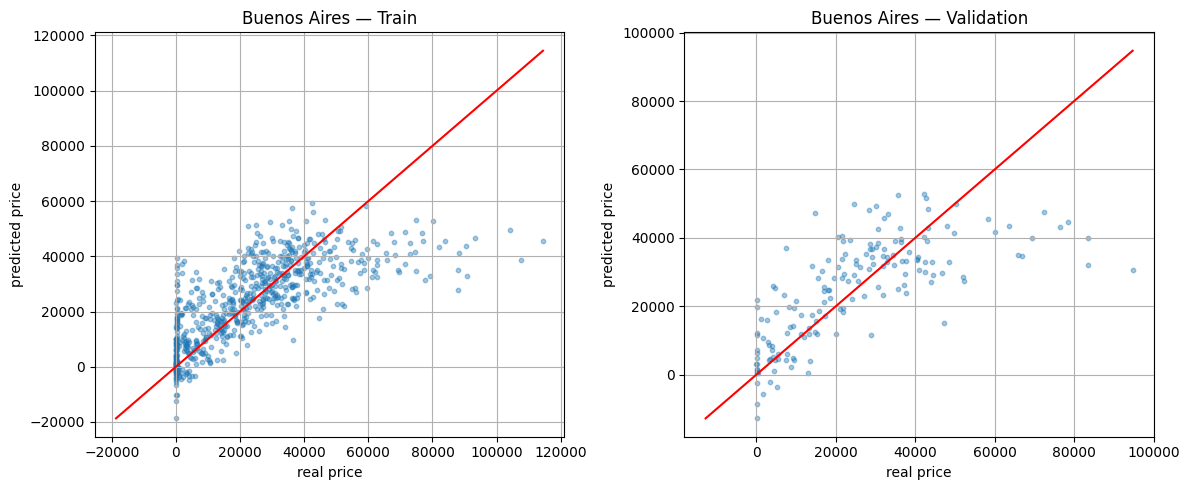

Nueva York - Model 4 (Train) - Metrics:
  MSE: 2263852056.65
  MAE: 37666.18
  RMSE: 47579.95
Nueva York - Model 4 (Validation) - Metrics:
  MSE: 2071307940.57
  MAE: 35596.27
  RMSE: 45511.62


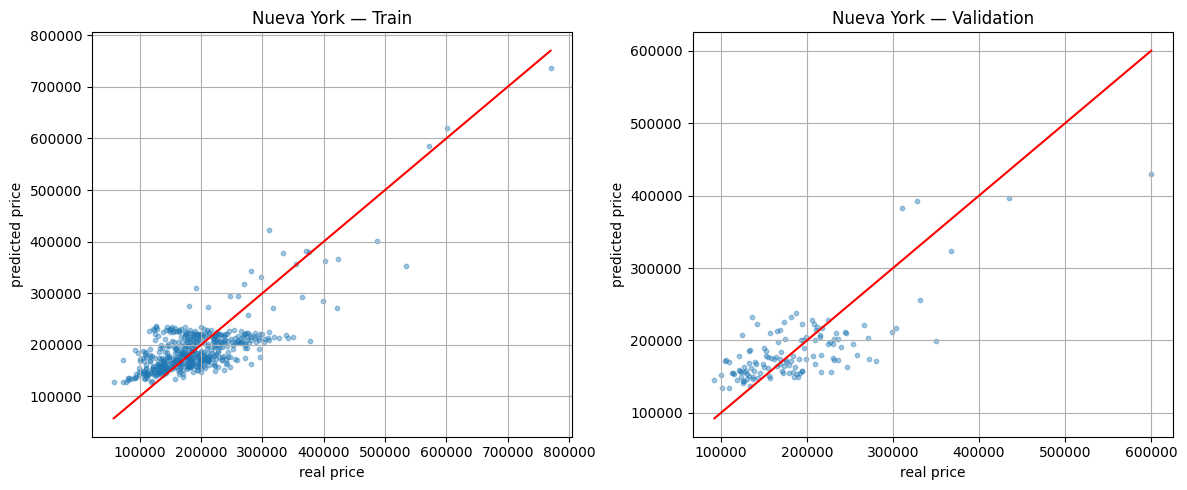

In [925]:
# M4: extends M3 with polynomial and ratio features — engineer, normalize, train, and evaluate
M4_dataBA = train_ba.copy()
M4_dataNY = train_ny.copy()

M4_val_ba = val_ba.copy()
M4_val_ny = val_ny.copy()

for data in [M4_dataBA, M4_dataNY, M4_val_ba, M4_val_ny]:
    data["ambientes_por_piso"] = data["ambientes"] / (data["pisos"])
    data["area_por_piso"] = data["Área"] / (data["pisos"])
    data["area_por_ambiente"] = data["Área"] / (data["ambientes"])
    data["ratio_cubierto"] = data["metros_cubiertos"] / (data["Área"])
    data["edad_cuadarada"] = data["edad"] ** 2
    data["Área^2"] = data["Área"] ** 2
    data["Área^3"] = data["Área"] ** 3
    data["metros_cubiertos^2"] = data["metros_cubiertos"] ** 2

M4_dataBA_norm, statistics_ba = normalize_train(M4_dataBA.copy(), M4_dataBA.columns)
M4_dataNY_norm, statistics_ny = normalize_train(M4_dataNY.copy(), M4_dataNY.columns)

M4_val_ba_norm = normalize_test(M4_val_ba.copy(), M4_dataBA.columns, statistics_ba)
M4_val_ny_norm = normalize_test(M4_val_ny.copy(), M4_dataNY.columns, statistics_ny)

featuresM4 = [
        "Área", "ambientes", "metros_cubiertos", 
        "edad", "pisos", "tipo_casa", "tipo_depto", "lat", "lon",
        "ambientes_por_piso", "area_por_piso", "area_por_ambiente",
        "ratio_cubierto", "edad_cuadarada", "Área^2", "Área^3", "metros_cubiertos^2"
    ]

city_datas_stats_M4 = [("Buenos Aires", M4_dataBA_norm, M4_val_ba, M4_val_ba_norm, statistics_ba), ("Nueva York", M4_dataNY_norm, M4_val_ny, M4_val_ny_norm, statistics_ny)]

for ciudad, data, val_data, val_data_norm, stats in city_datas_stats_M4:
    X4_train = data[featuresM4]
    y4 = data["precio"]

    X_valM4_norm = val_data_norm[featuresM4]
    y_valM4 = val_data["precio"]

    M4 = LinearRegression(X4_train, y4)
    M4.pseudo_inverse()

    _, y4_real, y4_pred = denormalize_dataset(M4, stats)

    print_metrics(y4_real, y4_pred, title=f"{ciudad} - Model 4 (Train)")

    y4_pred_val = denormalize_prediction(M4, X_valM4_norm, stats)

    print_metrics(y_valM4, y4_pred_val, title=f"{ciudad} - Model 4 (Validation)")
    
    plot_real_vs_pred(y4_real, y4_pred, y_valM4, y4_pred_val, title=ciudad)


BA cond: 685533.4500440116
Buenos Aires - Model 5 (Train) - Metrics:
  MSE: 159599468.13
  MAE: 8927.44
  RMSE: 12633.27
Buenos Aires - Model 5 (Validation) - Metrics:
  MSE: 154857559.25
  MAE: 8895.25
  RMSE: 12444.18


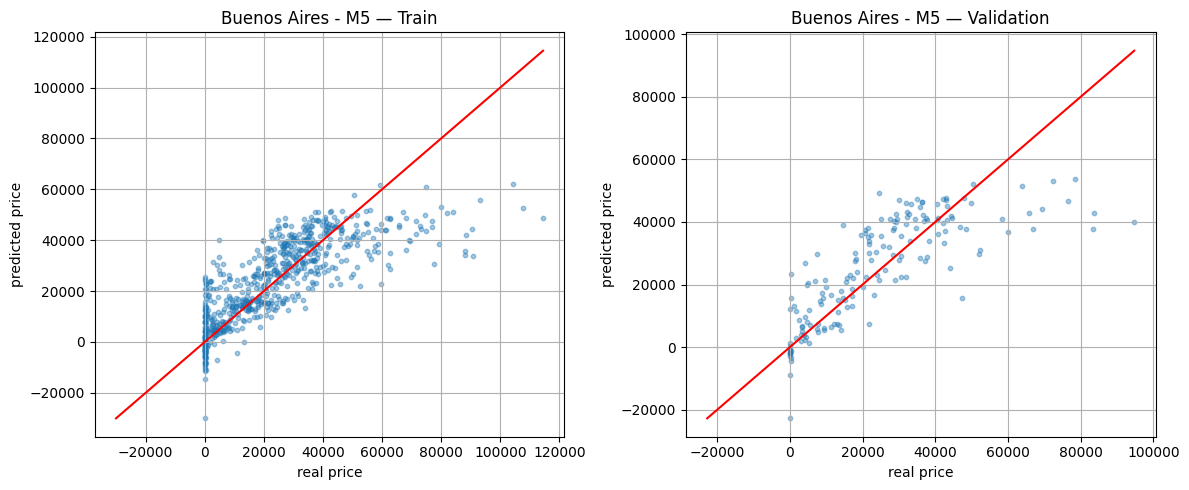

BA cond: 2.823067741186787e+16
Nueva York - Model 5 (Train) - Metrics:
  MSE: 1411190216.88
  MAE: 29306.16
  RMSE: 37565.81
Nueva York - Model 5 (Validation) - Metrics:
  MSE: 15628790390.46
  MAE: 44922.89
  RMSE: 125015.16


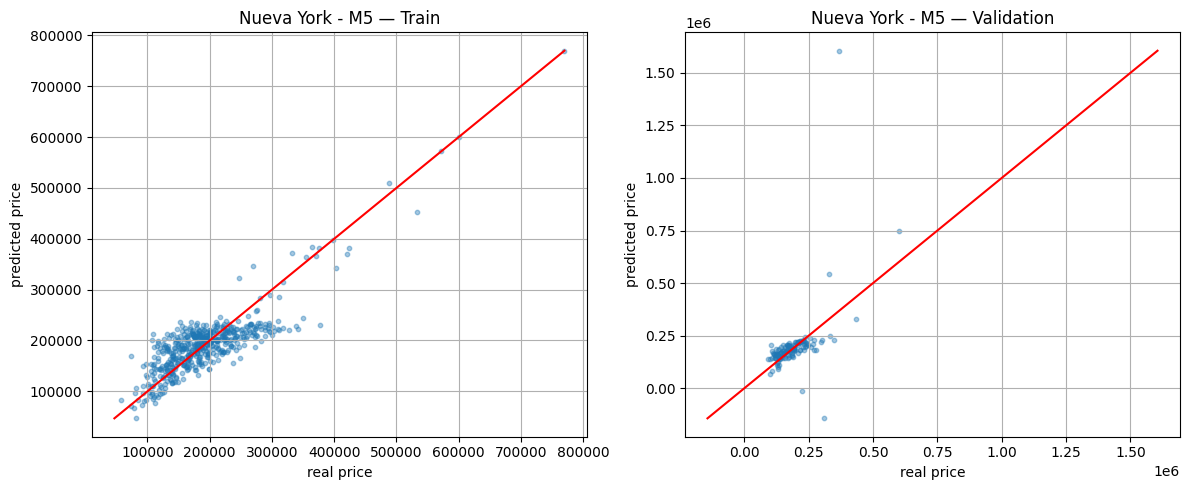

In [926]:
# M5: heavy feature engineering with polynomials, interactions, ratios, logs, and geo terms
new_dataBA = train_ba.copy()
new_dataNY = train_ny.copy()

new_val_ba = val_ba.copy()
new_val_ny = val_ny.copy()


for data in [new_dataBA, new_dataNY, new_val_ba, new_val_ny]:
    data["area^2"] = data["Área"] ** 2
    data["cubierto^2"] = data["metros_cubiertos"] ** 2
    data["edad^2"] = data["edad"] ** 2
    data["ambientes^2"] = data["ambientes"] ** 2
    data["pisos^2"] = data["pisos"] ** 2

    data["area^3"] = data["Área"] ** 3
    data["edad^3"] = data["edad"] ** 3

    # -------- SIMPLE INTERACTIONS --------
    data["area_x_cubierto"] = data["Área"] * data["metros_cubiertos"]
    data["area_x_ambientes"] = data["Área"] * data["ambientes"]
    data["area_x_edad"] = data["Área"] * data["edad"]
    data["cubierto_x_ambientes"] = data["metros_cubiertos"] * data["ambientes"]
    data["cubierto_x_edad"] = data["metros_cubiertos"] * data["edad"]
    data["ambientes_x_edad"] = data["ambientes"] * data["edad"]
    data["area_x_pisos"] = data["Área"] * data["pisos"]
    data["cubierto_x_pisos"] = data["metros_cubiertos"] * data["pisos"]

    # -------- QUADRATIC INTERACTIONS (controlled) --------
    data["area2_x_cubierto"] = (data["Área"] ** 2) * data["metros_cubiertos"]
    data["cubierto2_x_area"] = (data["metros_cubiertos"] ** 2) * data["Área"]

    data["area2_x_edad"] = (data["Área"] ** 2) * data["edad"]
    data["cubierto2_x_edad"] = (data["metros_cubiertos"] ** 2) * data["edad"]

    # -------- RATIOS --------
    data["area_por_ambiente"] = data["Área"] / (data["ambientes"] + 1e-5)
    data["area_por_piso"] = data["Área"] / (data["pisos"] + 1e-5)
    data["cubierto_por_area"] = data["metros_cubiertos"] / (data["Área"] + 1e-5)
    data["densidad"] = data["ambientes"] / (data["Área"] + 1e-5)

    # -------- TRANSFORMATIONS --------
    data["log_area"] = np.log(data["Área"] + 1)
    data["log_cubierto"] = np.log(data["metros_cubiertos"] + 1)
    data["sqrt_area"] = np.sqrt(data["Área"] + 1e-5)
    data["sqrt_cubierto"] = np.sqrt(data["metros_cubiertos"] + 1e-5)

    # -------- INVERSES (few, controlled) --------
    data["inv_area"] = 1 / (data["Área"] + 1e-5)
    data["inv_cubierto"] = 1 / (data["metros_cubiertos"] + 1e-5)
    data["sqrt_edad"] = np.sqrt(data["edad"] + 1e-5)

    # -------- GEO FEATURES --------
    data["lat^2"] = data["lat"] ** 2
    data["lon^2"] = data["lon"] ** 2
    data["lat_x_lon"] = data["lat"] * data["lon"]

    data["area_x_cubierto_x_ambientes"] = data["Área"] * data["metros_cubiertos"] * data["ambientes"]

    # -------- RATIO ROOTS --------

    data["sqrt_area_por_ambiente"] = np.sqrt(
        data["Área"] / (data["ambientes"] + 1e-5)
    )

    data["sqrt_cubierto_por_area"] = np.sqrt(
        data["metros_cubiertos"] / (data["Área"] + 1e-5)
    )

    # # -------- INTERACTION ROOTS --------

    data["sqrt_area_x_cubierto"] = np.sqrt(
        data["Área"] * data["metros_cubiertos"] + 1e-5
    )

    data["sqrt_area_x_ambientes"] = np.sqrt(
        data["Área"] * data["ambientes"] + 1e-5
    )

new_dataBA_norm, statistics_ba5 = normalize_train(new_dataBA.copy(), new_dataBA.columns)
new_dataNY_norm, statistics_ny5 = normalize_train(new_dataNY.copy(), new_dataNY.columns)

# Normalize val with the same statistics
new_val_ba_norm = normalize_test(new_val_ba.copy(), new_dataBA.columns, statistics_ba5)
new_val_ny_norm = normalize_test(new_val_ny.copy(), new_dataNY.columns, statistics_ny5)


featuresM5 = [col for col in new_dataBA_norm.columns if col != "precio"]

city_datas_M5 = [
    ("Buenos Aires", new_dataBA_norm, new_val_ba, new_val_ba_norm, statistics_ba5),
    ("Nueva York",   new_dataNY_norm, new_val_ny, new_val_ny_norm, statistics_ny5),
]

for ciudad, train_data, val_data, val_data_norm, stats in city_datas_M5:
    if ciudad == "Nueva York":
        if "pileta" in featuresM5:
            featuresM5.remove("pileta")

    X5_train = train_data[featuresM5]
    y5_train = train_data["precio"]
    X5_val   = val_data_norm[featuresM5]
    y5_val   = val_data["precio"]

    print("BA cond:", np.linalg.cond(X5_train))
    M5 = LinearRegression(X5_train, y5_train)
    M5.pseudo_inverse()
    
    
    
    # Denormalize train
    _, y_train_real, y_train_pred = denormalize_dataset(M5, stats)

    print_metrics(y_train_real, y_train_pred, title=f"{ciudad} - Model 5 (Train)")

    y5_val_pred = denormalize_prediction(M5, X5_val, stats)

    print_metrics(y5_val, y5_val_pred, title=f"{ciudad} - Model 5 (Validation)")

    plot_real_vs_pred(y_train_real, y_train_pred, y5_val, y5_val_pred, title=f"{ciudad} - M5")

It was expected that Model M4 would outperform M3 in both training and validation, as the inclusion of non-linear features generally improves predictive performance. Additionally, for M5, one would typically expect signs of overfitting, with very good performance on the training set but worse results on validation.

In the case of M4, the results were consistent with expectations: performance improved compared to M3, although the gains were moderate in both Buenos Aires and New York.

For M5, the results were somewhat surprising. In Buenos Aires, the model did not achieve better performance on the training set than on the validation set, in fact, validation performance was even slightly better with no signs of overfitting. In contrast, in New York, M5 did exhibit overfitting behavior, with a larger gap between training and validation errors. Even though the New York dataset exhibits some overfitting, Model M5 still shows strong potential as a predictor when combined with appropriate regularization.

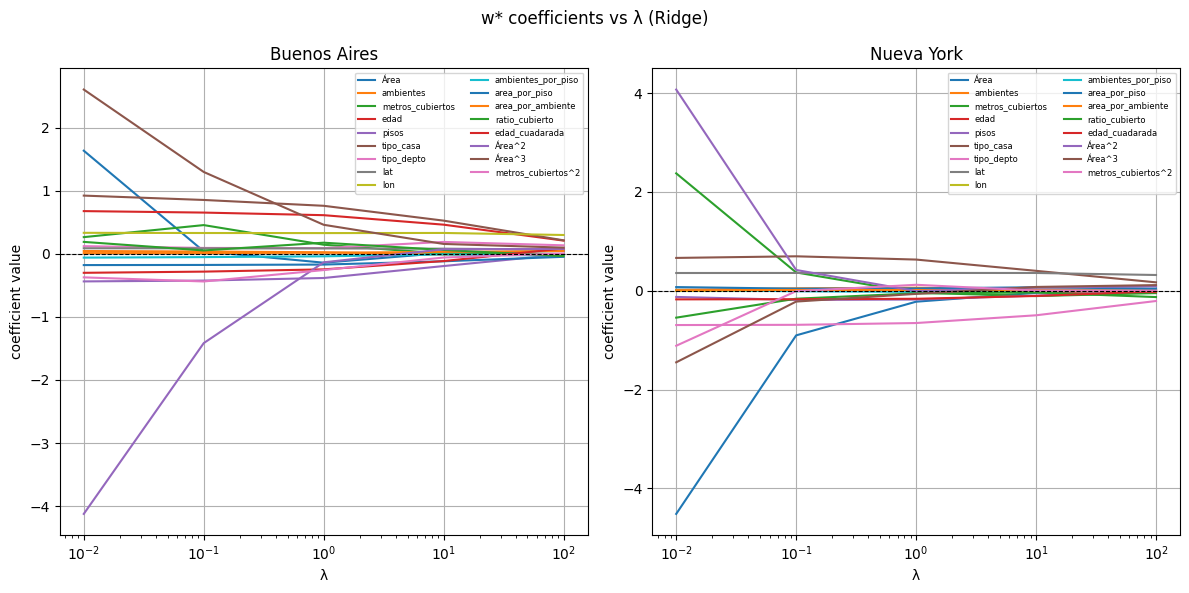

In [927]:
# Ridge regularization path: plot how each coefficient shrinks as lambda increases
city_datas_stats = [("Buenos Aires", M4_dataBA_norm, statistics_ba), ("Nueva York", M4_dataNY_norm, statistics_ny)]

lambdas = [0.01, 0.1, 1, 10, 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
i = 0

for ciudad, data, stats in city_datas_stats:
    X4 = data[featuresM4]
    y = data["precio"]
    
    coefs_por_lambda = []
    for ridge in lambdas:
        M4 = LinearRegression(X4, y, L2=ridge)
        M4.pseudo_inverse()
        coefs_por_lambda.append(M4.coef[1:]) 

    coefs_por_lambda = np.array(coefs_por_lambda) 

    ax = axes[i]
    for j, feature in enumerate(featuresM4):
        ax.plot(lambdas, coefs_por_lambda[:, j], label=feature)

    ax.set_xscale("log")
    ax.set_xlabel("λ")
    ax.set_ylabel("coefficient value")
    ax.set_title(ciudad)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True)
    i += 1

plt.suptitle("w* coefficients vs λ (Ridge)")
plt.tight_layout()
plt.show()


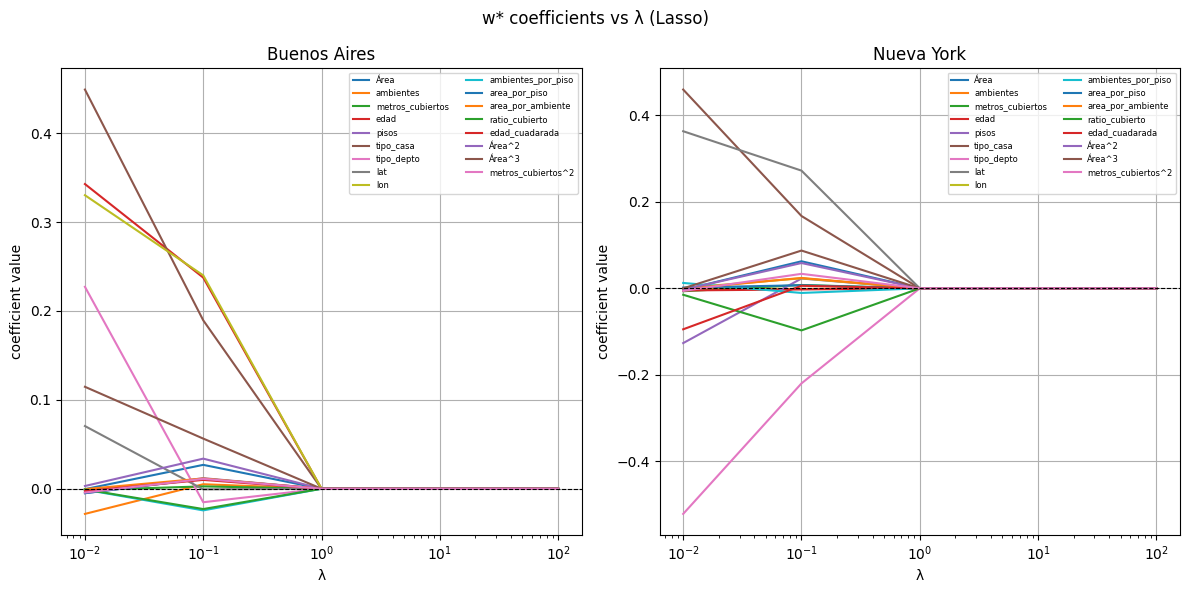

In [928]:
# Lasso regularization path: same as Ridge but solved via gradient descent
lambdas = [0.01, 0.1, 1, 10, 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
i = 0

for ciudad, data, stats in city_datas_stats:
    X4 = data[featuresM4]
    y = data["precio"]
    
    coefs_por_lambda = []
    for lasso in lambdas:
        M4 = LinearRegression(X4, y, L1=lasso)
        M4.gradient_descent()
        coefs_por_lambda.append(M4.coef[1:]) 

    coefs_por_lambda = np.array(coefs_por_lambda) 

    ax = axes[i]
    for j, feature in enumerate(featuresM4):
        ax.plot(lambdas, coefs_por_lambda[:, j], label=feature)

    ax.set_xscale("log")
    ax.set_xlabel("λ")
    ax.set_ylabel("coefficient value")
    ax.set_title(ciudad)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True)

    i += 1

plt.suptitle("w* coefficients vs λ (Lasso)")
plt.tight_layout()
plt.show()

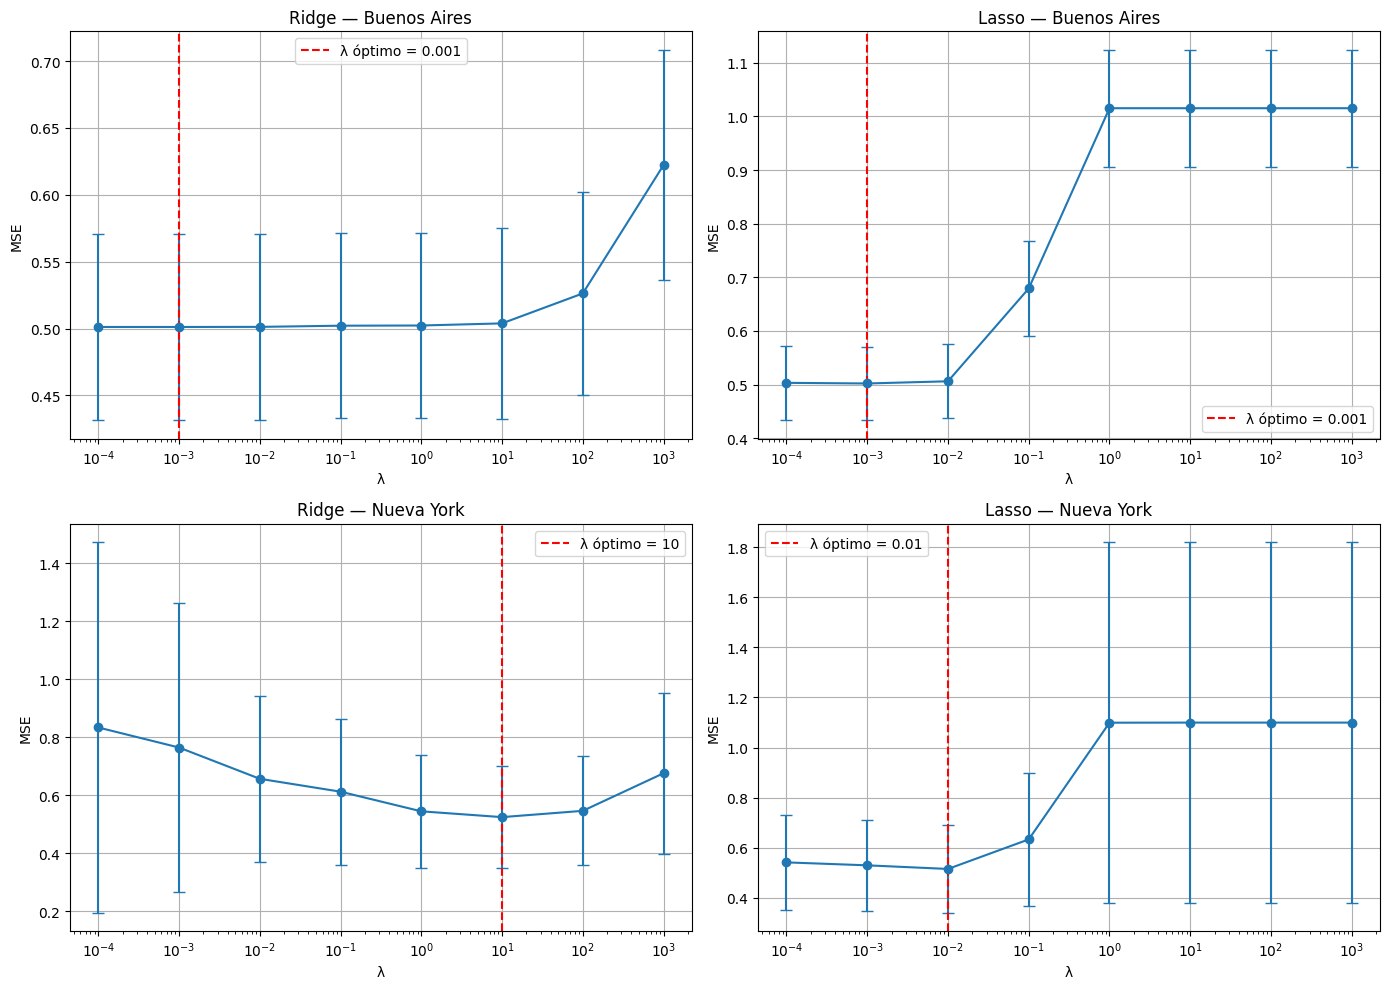

In [929]:
# K-fold cross-validation to select the optimal lambda for both Ridge and Lasso
lambdas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
city_data = [("Buenos Aires", M4_dataBA_norm), ("Nueva York", M4_dataNY_norm)]

fig, axes = plt.subplots(len(city_data), 2, figsize=(14, 10))

for i, (ciudad, data) in enumerate(city_data):

    # -------- RIDGE --------
    ridge_means, ridge_stds = [], []
    for lam in lambdas:
        mean, std = cross_val(data, featuresM4, "precio", k=5, L2=lam)
        ridge_means.append(mean)
        ridge_stds.append(std)

    ax_ridge = axes[i, 0]

    ax_ridge.errorbar(lambdas, ridge_means, yerr=ridge_stds, marker="o", capsize=4)
    ax_ridge.set_xscale("log")
    ax_ridge.set_xlabel("λ")
    ax_ridge.set_ylabel("MSE")
    ax_ridge.set_title(f"Ridge — {ciudad}")
    ax_ridge.grid(True)

    best_ridge = lambdas[np.argmin(ridge_means)]
    ax_ridge.axvline(best_ridge, color="red", linestyle="--", label=f"λ óptimo = {best_ridge}")
    ax_ridge.legend()

    # -------- LASSO --------
    lasso_means, lasso_stds = [], []
    for lam in lambdas:
        mean, std = cross_val(data, featuresM4, "precio", k=5, L1=lam)
        lasso_means.append(mean)
        lasso_stds.append(std)

    ax_lasso = axes[i, 1]

    ax_lasso.errorbar(lambdas, lasso_means, yerr=lasso_stds, marker="o", capsize=4)
    ax_lasso.set_xscale("log")
    ax_lasso.set_xlabel("λ")
    ax_lasso.set_ylabel("MSE")
    ax_lasso.set_title(f"Lasso — {ciudad}")
    ax_lasso.grid(True)

    best_lasso = lambdas[np.argmin(lasso_means)]
    ax_lasso.axvline(best_lasso, color="red", linestyle="--", label=f"λ óptimo = {best_lasso}")
    ax_lasso.legend()

plt.tight_layout()
plt.show()

M6 = LinearRegression(X4, y, L2=best_ridge)
ridge_weights = M6.pseudo_inverse()

M7 = LinearRegression(X4, y, L1=best_lasso)
lasso_weights = M7.gradient_descent()


==================== Buenos Aires ====================


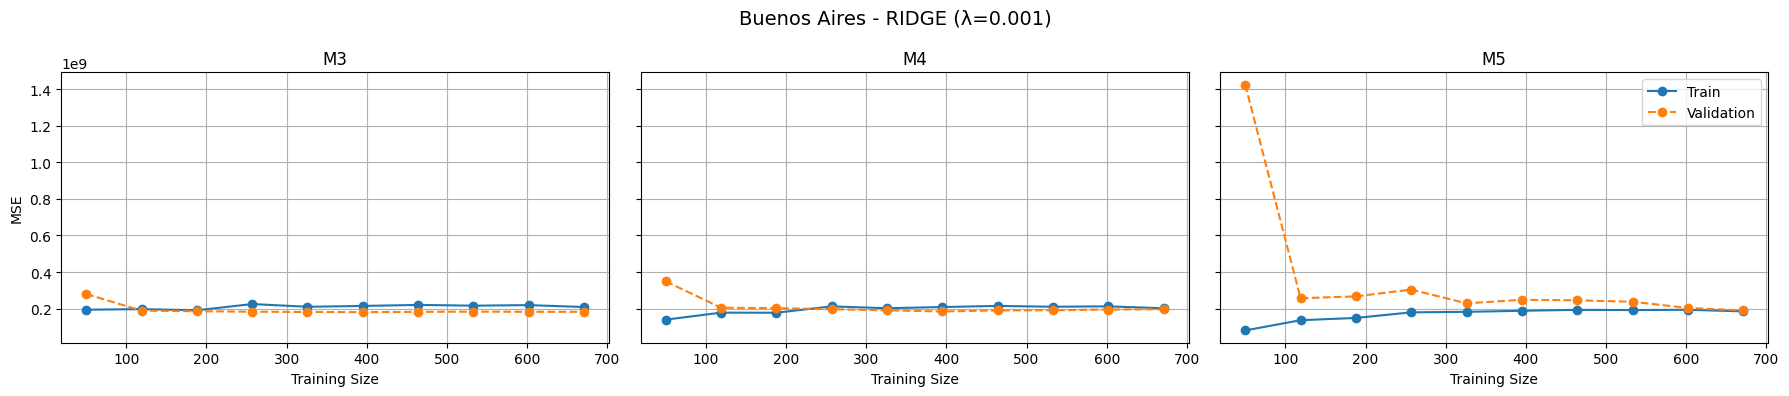

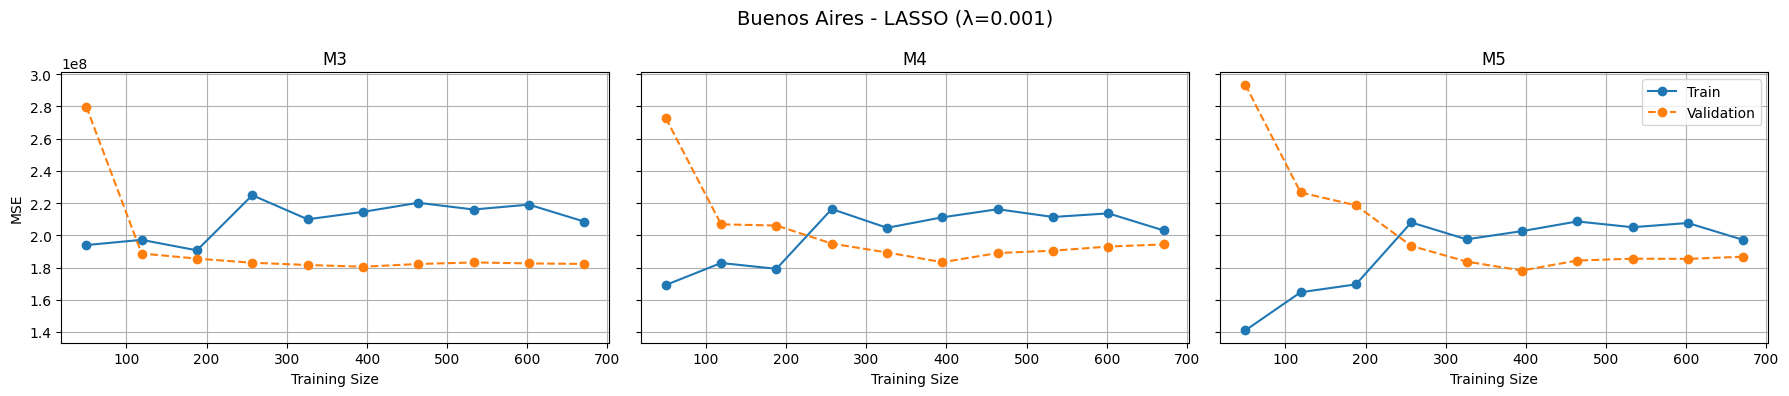


==================== Nueva York ====================


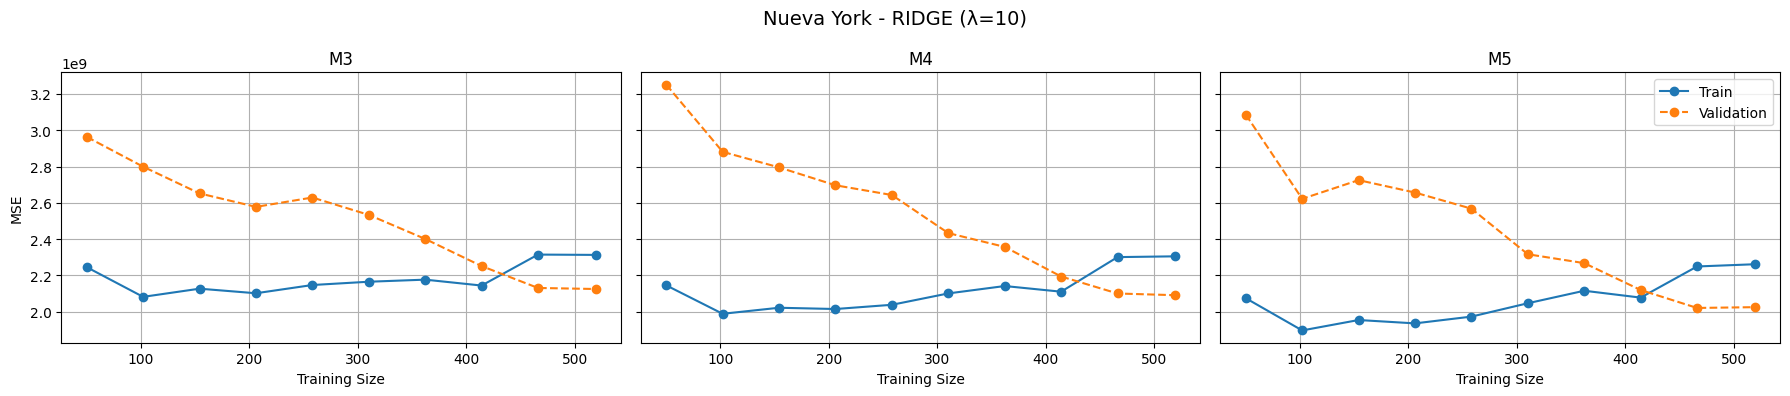

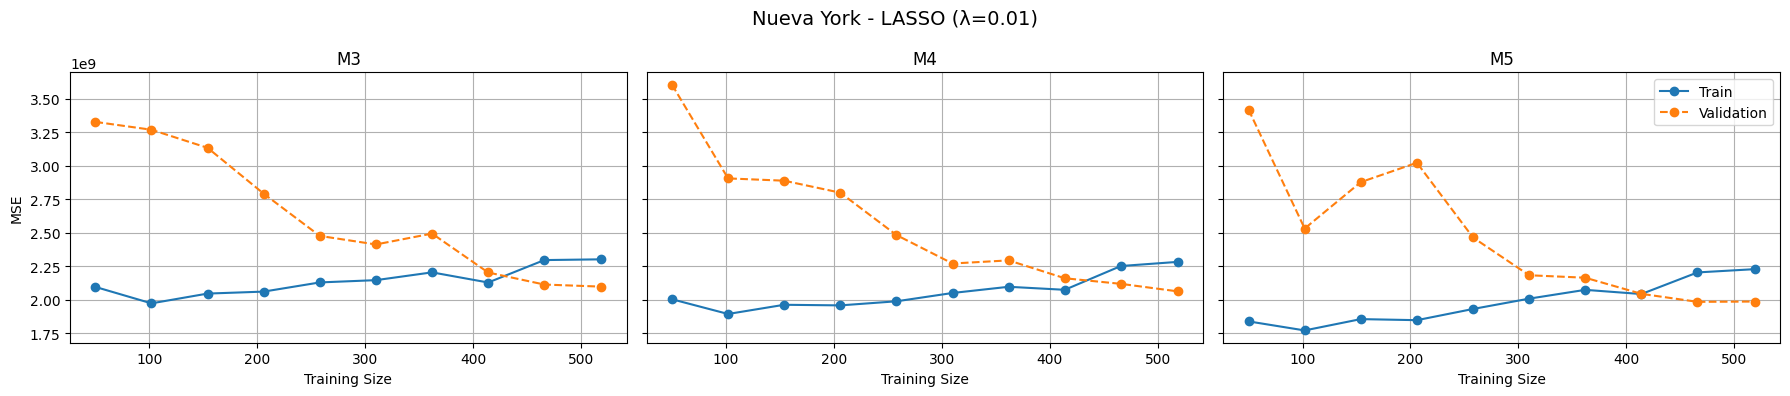

In [930]:
# Learning curves for M3, M4, and M5 under each regularizer — one subplot per model
ridge_ba = 0.001
lasso_ba = 0.001

ridge_ny = 10
lasso_ny = 0.01

models_features = {
    "M3": featuresM3,
    "M4": featuresM4,
    "M5": featuresM5
}

city_configs = [
    ("Buenos Aires", train_ba, val_ba, ridge_ba, lasso_ba),
    ("Nueva York",   train_ny, val_ny, ridge_ny, lasso_ny)
]

for ciudad, train_data, val_data, ridge_lambda, lasso_lambda in city_configs:

    print(f"\n==================== {ciudad} ====================")

    for reg_name, lambd in [("Ridge", ridge_lambda), ("Lasso", lasso_lambda)]:

        fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)
        fig.suptitle(f"{ciudad} - {reg_name.upper()} (λ={lambd})", fontsize=14)

        for i, (model_name, features) in enumerate(models_features.items()):

            train_feat = build_features(train_data, model_name)
            val_feat = build_features(val_data, model_name)

            X = train_feat[features]
            X, stats = normalize_train(X.copy(), features)
            y = train_feat["precio"]

            X_val = val_feat[features]
            X_val = normalize_test(X_val.copy(), features, stats)
            y_val = val_feat["precio"]

            sizes, train_err, val_err = learning_curve(
                LinearRegression, X, y, X_val, y_val, reg_name, lambd
            )

            ax = axes[i]

            ax.plot(sizes, train_err, marker="o", label="Train")
            ax.plot(sizes, val_err, marker="o", linestyle="--", label="Validation")

            ax.set_title(model_name)
            ax.set_xlabel("Training Size")
            ax.grid(True)

            if i == 0:
                ax.set_ylabel("MSE")

        axes[-1].legend(loc="best")
        plt.tight_layout()
        plt.show()

The learning curves show a somewhat unusual pattern, where the training error is occasionally higher than the validation error and exhibits a slightly irregular shape. This behavior is not typical, but it can be explained by factors such as regularization effects and the way training subsets are constructed. Importantly, this pattern is consistent across models and does not invalidate the comparison.

Based on the observed results, I would select Model M5 with ridge regularization as the model to deploy in production. Across both datasets, M5 consistently achieves the lowest validation error, outperforming M3 and M4. This indicates that the additional polynomial and interaction features are effectively capturing relevant structure in the data, leading to improved predictive accuracy. Importantly, the learning curves do not show evidence of overfitting. In fact, in several cases, the validation error is comparable to or even slightly lower than the training error. Additionally, both curves tend to converge as the training size increases, suggesting that the model generalizes well and does not suffer from high variance. This behavior indicates a well-balanced model where regularization is successfully controlling complexity, allowing M5 to benefit from richer feature representations without degrading generalization performance. Furthermore, the validation error continues to decrease as more data is added, which suggests that the model is data-efficient and scalable, making it suitable for production environments where additional data may become available over time.

Buenos Aires - M5 Ridge TEST (λ=0.001) - Metrics:
  MSE: 189855785.35
  MAE: 9500.74
  RMSE: 13778.82


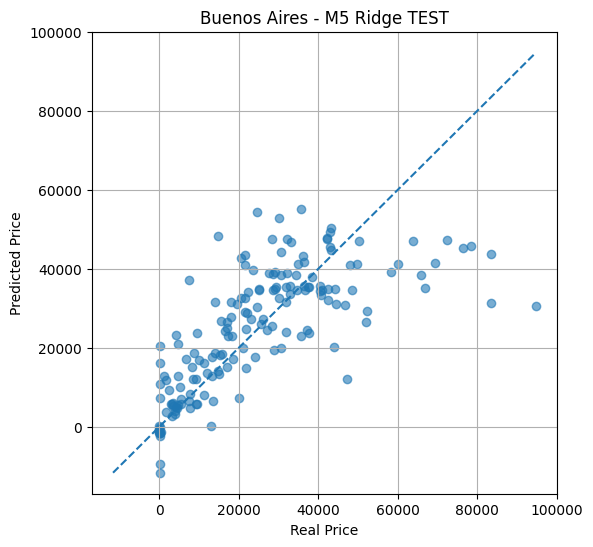

Nueva York - M5 Ridge TEST (λ=10) - Metrics:
  MSE: 2024357045.04
  MAE: 34668.14
  RMSE: 44992.86


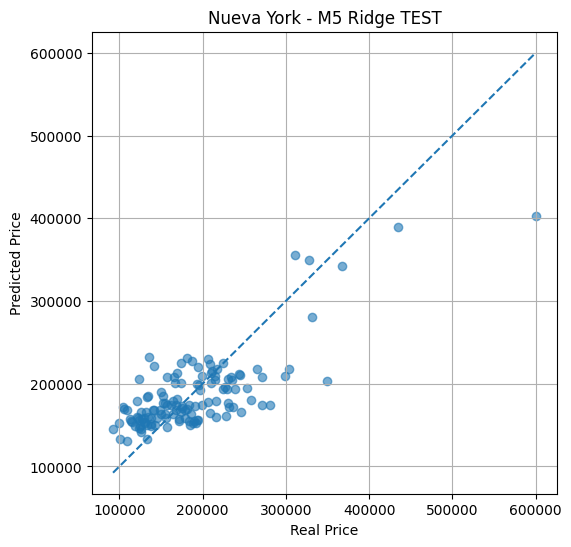

In [931]:
# Final evaluation on the test set using the best M5 + Ridge configuration per city
for ciudad, train_data, test_data, test_data_norm, stats in city_datas_M5:

    # set lambda per city
    if ciudad == "Buenos Aires":
        ridge_lambda = 0.001
    elif ciudad == "Nueva York":
        ridge_lambda = 10

    # avoid mutating the global features list
    features = featuresM5.copy()

    if ciudad == "Nueva York" and "pileta" in features:
        features.remove("pileta")

    # -------- DATA --------
    X_train = train_data[features]
    y_train = train_data["precio"]

    X_test = test_data_norm[features]
    y_test = test_data["precio"]

    # -------- MODEL --------
    M5 = LinearRegression(X_train, y_train)
    M5.L2 = ridge_lambda
    M5.pseudo_inverse()

    # -------- PRED TEST --------
    y_test_pred = denormalize_prediction(M5, X_test, stats)

    # -------- TEST METRICS --------
    print_metrics(y_test, y_test_pred, title=f"{ciudad} - M5 Ridge TEST (λ={ridge_lambda})")

    # -------- TEST PLOT --------
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_test_pred, alpha=0.6)

    # ideal diagonal
    min_val = min(y_test.min(), y_test_pred.min())
    max_val = max(y_test.max(), y_test_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.xlabel("Real Price")
    plt.ylabel("Predicted Price")
    plt.title(f"{ciudad} - M5 Ridge TEST")
    plt.grid(True)
    plt.show()